# Neural Networks with TensorFlow/Keras

## Objective
Build a simple feed-forward neural network using TensorFlow/Keras for classification tasks (MNIST digit classification).

### Tasks:
- Load and preprocess the dataset
- Design a neural network architecture (input layer, hidden layers, and output layer)
- Train the model using backpropagation
- Evaluate the model using accuracy and visualize the training/validation loss

## 1. Import Required Libraries

In [22]:
# pip install tensorflow keras scikit-learn pandas numpy matplotlib seaborn

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


import warnings
warnings.filterwarnings('ignore', category=ImportWarning)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.11.3


## 2. Load and Explore the MNIST Dataset

The MNIST dataset contains 70,000 grayscale images of handwritten digits (0-9), each 28x28 pixels.

In [24]:
# Load the MNIST dataset (built-in with Keras)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Display dataset information
print("Dataset Information:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Image shape: {X_train.shape[1:]} pixels")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples")

Dataset Information:
Training set: 60000 samples
Test set: 10000 samples
Image shape: (28, 28) pixels
Number of classes: 10

Class distribution in training set:
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


### Visualize Sample Images

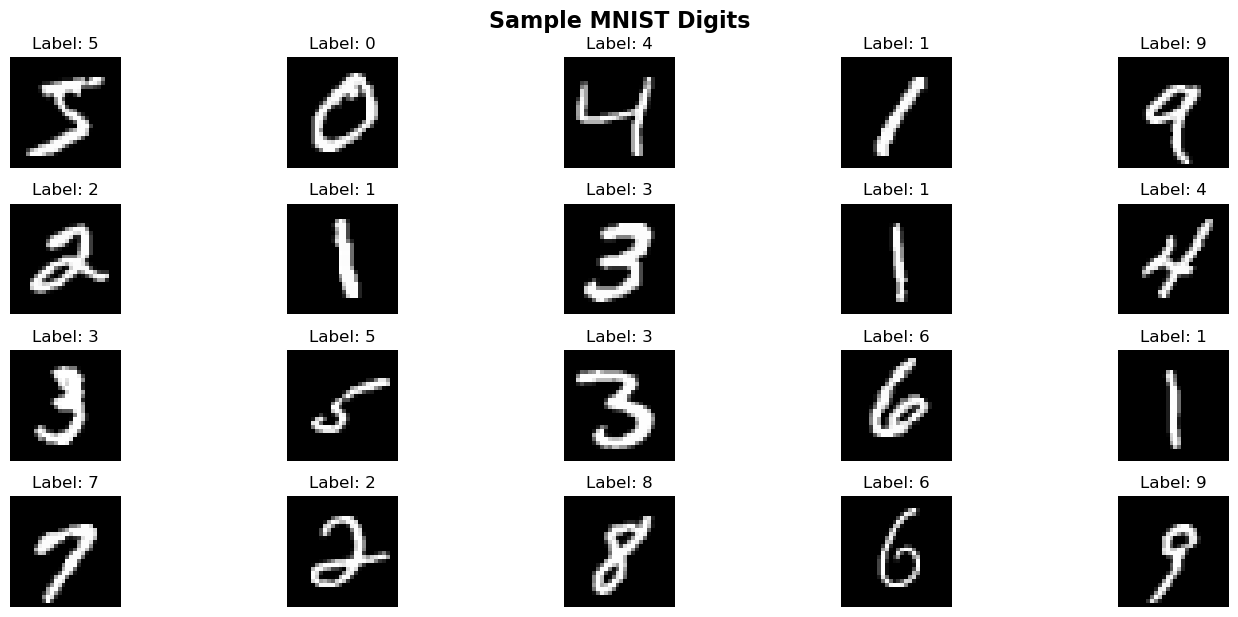

In [25]:
# Visualize some sample images
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Sample MNIST Digits', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## 3. Data Preprocessing

Steps:
- Normalize pixel values to [0, 1] range
- Flatten images for feed-forward network
- One-hot encode labels

In [26]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# Flatten the images from 28x28 to 784 (for feed-forward network)
X_train_flattened = X_train_normalized.reshape(-1, 28*28)
X_test_flattened = X_test_normalized.reshape(-1, 28*28)

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print("After Preprocessing:")
print(f"X_train shape: {X_train_flattened.shape}")
print(f"X_test shape: {X_test_flattened.shape}")
print(f"y_train shape: {y_train_encoded.shape}")
print(f"y_test shape: {y_test_encoded.shape}")
print(f"\nSample normalized pixel range: [{X_train_flattened.min():.2f}, {X_train_flattened.max():.2f}]")
print(f"Sample one-hot encoded label: {y_train_encoded[0]} (Original: {y_train[0]})")

After Preprocessing:
X_train shape: (60000, 784)
X_test shape: (10000, 784)
y_train shape: (60000, 10)
y_test shape: (10000, 10)

Sample normalized pixel range: [0.00, 1.00]
Sample one-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] (Original: 5)


## 4. Design Neural Network Architecture

We'll build a feed-forward neural network with:
- **Input Layer**: 784 neurons (28x28 flattened image)
- **Hidden Layer 1**: 128 neurons with ReLU activation
- **Dropout Layer 1**: 20% dropout for regularization
- **Hidden Layer 2**: 64 neurons with ReLU activation
- **Dropout Layer 2**: 20% dropout for regularization
- **Output Layer**: 10 neurons with Softmax activation (for 10 classes)

In [27]:
# Build the neural network model
model = Sequential([
    # Input layer (implicit) + First hidden layer
    Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    Dropout(0.2, name='dropout_1'),
    
    # Second hidden layer
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dropout(0.2, name='dropout_2'),
    
    # Output layer
    Dense(10, activation='softmax', name='output_layer')
])

# Display model architecture
print("Neural Network Architecture:")
print("="*60)
model.summary()
print("="*60)

Neural Network Architecture:


c:\Users\Jahidul\anaconda3\envs\py11\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Visualize Model Architecture

In [28]:
# pip install pydot graphviz

In [29]:
# # Visualize the model architecture (requires graphviz)
# # Note: To use plot_model, install graphviz from https://graphviz.gitlab.io/download/
# # and then install pydot: pip install pydot graphviz

# try:
#     keras.utils.plot_model(
#         model, 
#         to_file='model_architecture.png', 
#         show_shapes=True, 
#         show_layer_names=True,
#         rankdir='TB',
#         dpi=96
#     )
    
#     from IPython.display import Image
#     display(Image('model_architecture.png'))
#     print("Model architecture diagram saved as 'model_architecture.png'")
# except Exception as e:
#     print(f"Unable to create visual diagram: {e}")
#     print("\nAlternative: Model architecture summary above shows all layers and parameters.")
#     print("To enable diagram visualization, install graphviz:")
#     print("  1. Download from: https://graphviz.gitlab.io/download/")
#     print("  2. Install and add to system PATH")
#     print("  3. Run: pip install pydot graphviz")

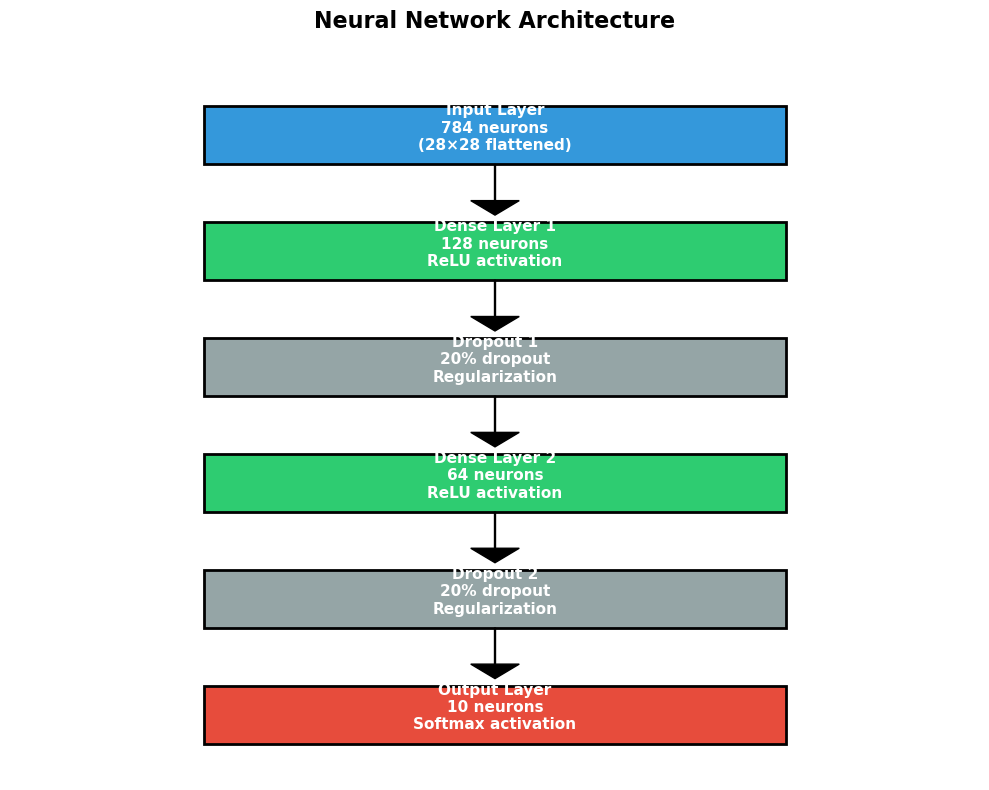


Total Trainable Parameters: 109,386


In [30]:
# Alternative: Simple visualization using matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')

# Define layer information
layers_info = [
    ("Input Layer", "784 neurons", "(28×28 flattened)"),
    ("Dense Layer 1", "128 neurons", "ReLU activation"),
    ("Dropout 1", "20% dropout", "Regularization"),
    ("Dense Layer 2", "64 neurons", "ReLU activation"),
    ("Dropout 2", "20% dropout", "Regularization"),
    ("Output Layer", "10 neurons", "Softmax activation")
]

# Draw the architecture
y_positions = np.linspace(0.9, 0.1, len(layers_info))
colors = ['#3498db', '#2ecc71', '#95a5a6', '#2ecc71', '#95a5a6', '#e74c3c']

for i, (layer_name, neurons, activation) in enumerate(layers_info):
    # Draw rectangle for each layer
    rect = plt.Rectangle((0.2, y_positions[i] - 0.05), 0.6, 0.08, 
                          facecolor=colors[i], edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    
    # Add text
    ax.text(0.5, y_positions[i], f"{layer_name}\n{neurons}\n{activation}", 
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Draw arrows between layers
    if i < len(layers_info) - 1:
        ax.arrow(0.5, y_positions[i] - 0.05, 0, -0.05, 
                head_width=0.05, head_length=0.02, fc='black', ec='black')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title('Neural Network Architecture', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print total parameters
total_params = sum([np.prod(p.shape) for p in model.trainable_weights])
print(f"\nTotal Trainable Parameters: {total_params:,}")

## 5. Compile the Model

Configure the model with:
- **Optimizer**: Adam (adaptive learning rate)
- **Loss Function**: Categorical Crossentropy (for multi-class classification)
- **Metrics**: Accuracy

In [31]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Optimizer: Adam")
print(f"Loss Function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam
Loss Function: Categorical Crossentropy
Metrics: Accuracy


## 6. Train the Model (Backpropagation)

We'll train the model with:
- **Epochs**: 20
- **Batch Size**: 128
- **Validation Split**: 20% of training data
- **Early Stopping**: To prevent overfitting

In [32]:
# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("Training the Neural Network...")
print("="*60)

history = model.fit(
    X_train_flattened, 
    y_train_encoded,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("="*60)
print("Training completed!")

Training the Neural Network...
Epoch 1/20
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8482 - loss: 0.5043 - val_accuracy: 0.9438 - val_loss: 0.1896
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8482 - loss: 0.5043 - val_accuracy: 0.9438 - val_loss: 0.1896
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9335 - loss: 0.2277 - val_accuracy: 0.9588 - val_loss: 0.1365
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9335 - loss: 0.2277 - val_accuracy: 0.9588 - val_loss: 0.1365
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9494 - loss: 0.1695 - val_accuracy: 0.9661 - val_loss: 0.1153
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9494 - loss: 0.1695 - val_accuracy: 0.9661 - val_loss: 0.1153
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9581 - loss: 0.1393 - val_accuracy: 0.9690 - val_loss: 0.1051
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

## 7. Visualize Training History

Analyze the training and validation loss/accuracy curves to check for overfitting or underfitting.

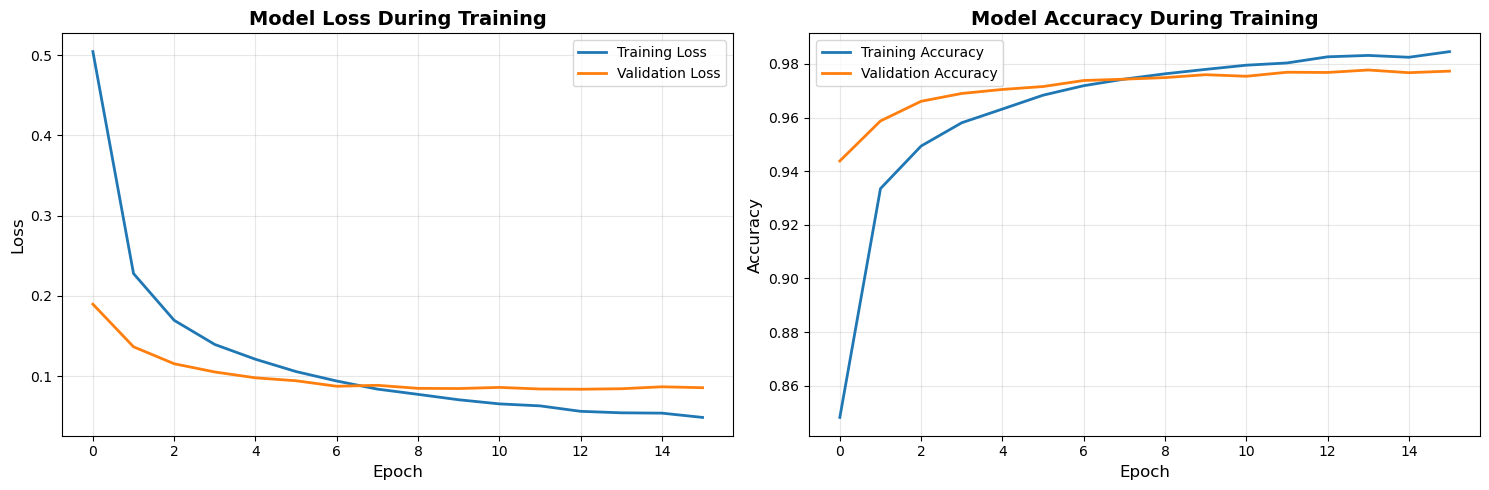


Final Training Metrics:
Training Loss: 0.0484
Training Accuracy: 0.9846
Validation Loss: 0.0855
Validation Accuracy: 0.9773


In [33]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final training metrics
print("\nFinal Training Metrics:")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 8. Evaluate the Model on Test Set

In [34]:
# Evaluate on test set
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(X_test_flattened, y_test_encoded, verbose=0)

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

Evaluating model on test set...

TEST SET PERFORMANCE
Test Loss: 0.0812
Test Accuracy: 0.9773 (97.73%)

TEST SET PERFORMANCE
Test Loss: 0.0812
Test Accuracy: 0.9773 (97.73%)


## 9. Make Predictions and Analyze Results

In [35]:
# Make predictions on test set
y_pred_probabilities = model.predict(X_test_flattened, verbose=0)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

print("Predictions generated!")
print(f"Shape of predictions: {y_pred_probabilities.shape}")
print(f"\nSample prediction (probabilities):")
print(f"Image 0 - Predicted: {y_pred_classes[0]}, Actual: {y_test[0]}")
print(f"Probabilities: {y_pred_probabilities[0]}")

Predictions generated!
Shape of predictions: (10000, 10)

Sample prediction (probabilities):
Image 0 - Predicted: 7, Actual: 7
Probabilities: [3.0056572e-08 1.1405192e-07 5.8230198e-06 1.4508570e-06 4.1937214e-11
 1.3686484e-08 6.9602245e-13 9.9999261e-01 2.0784206e-10 4.6598373e-08]


### Classification Report

In [36]:
# Generate classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_classes, target_names=[str(i) for i in range(10)]))
print("="*60)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.98       892
           6       0.97      0.99      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Confusion Matrix

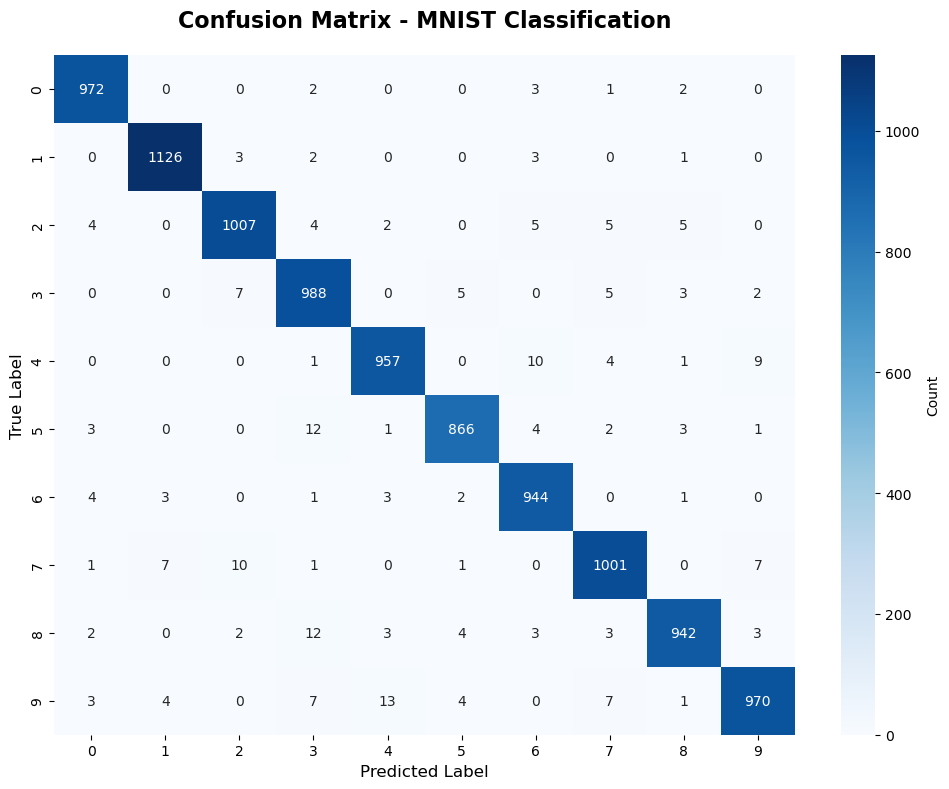


Per-Class Accuracy:
Digit 0: 0.9918 (99.18%)
Digit 1: 0.9921 (99.21%)
Digit 2: 0.9758 (97.58%)
Digit 3: 0.9782 (97.82%)
Digit 4: 0.9745 (97.45%)
Digit 5: 0.9709 (97.09%)
Digit 6: 0.9854 (98.54%)
Digit 7: 0.9737 (97.37%)
Digit 8: 0.9671 (96.71%)
Digit 9: 0.9613 (96.13%)


In [37]:
# Generate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - MNIST Classification', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
print("="*60)
for i in range(10):
    class_accuracy = cm[i, i] / cm[i].sum()
    print(f"Digit {i}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

## 10. Visualize Predictions

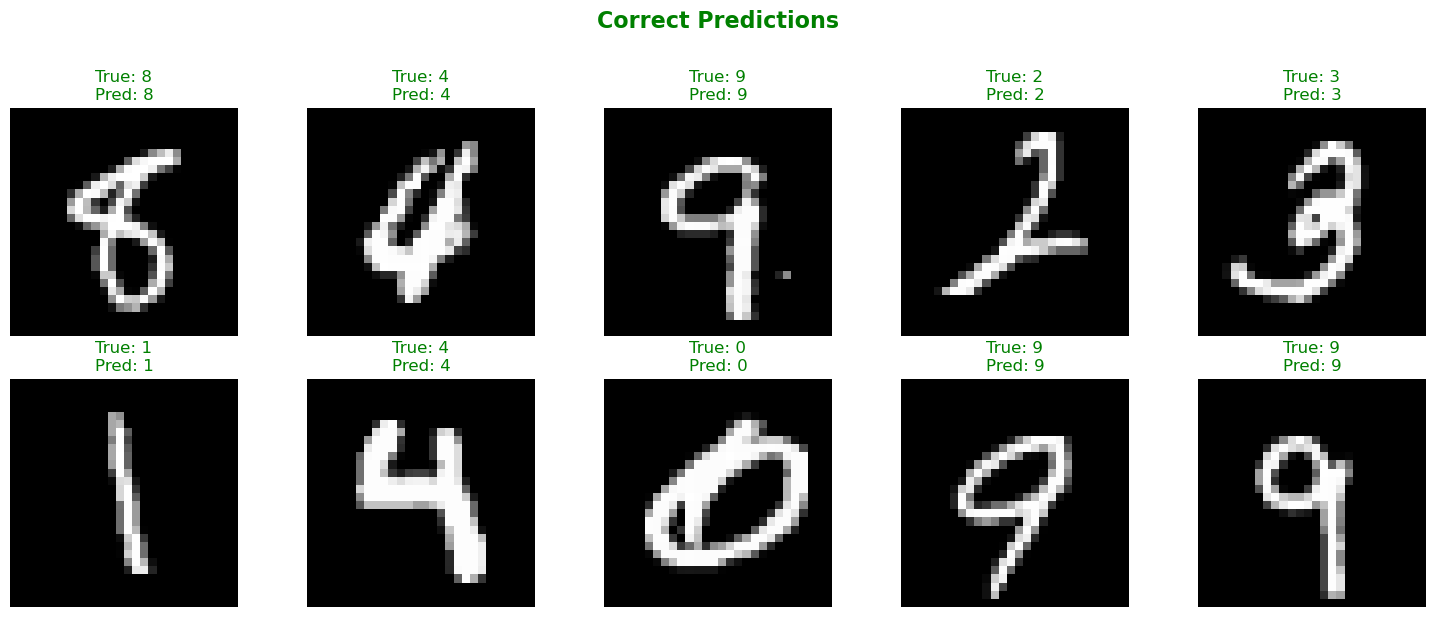

In [38]:
# Visualize correct predictions
correct_indices = np.where(y_pred_classes == y_test)[0]
np.random.shuffle(correct_indices)

plt.figure(figsize=(15, 6))
for i in range(10):
    idx = correct_indices[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'True: {y_test[idx]}\nPred: {y_pred_classes[idx]}', color='green')
    plt.axis('off')
plt.suptitle('Correct Predictions', fontsize=16, fontweight='bold', color='green', y=1.02)
plt.tight_layout()
plt.show()

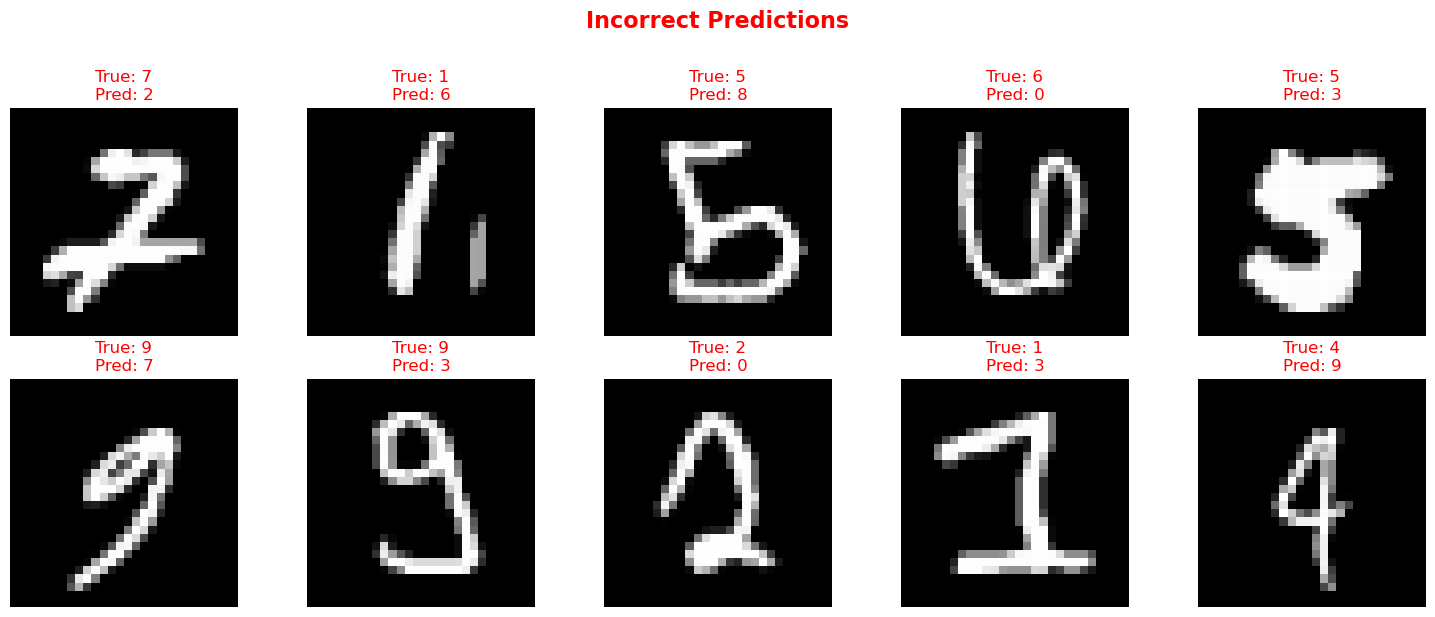

In [39]:
# Visualize incorrect predictions
incorrect_indices = np.where(y_pred_classes != y_test)[0]
np.random.shuffle(incorrect_indices)

if len(incorrect_indices) > 0:
    plt.figure(figsize=(15, 6))
    num_to_show = min(10, len(incorrect_indices))
    for i in range(num_to_show):
        idx = incorrect_indices[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        plt.title(f'True: {y_test[idx]}\nPred: {y_pred_classes[idx]}', color='red')
        plt.axis('off')
    plt.suptitle('Incorrect Predictions', fontsize=16, fontweight='bold', color='red', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions found!")

## 11. Model Summary

### Findings:
1. **Architecture**: Feed-forward neural network with 2 hidden layers (128 and 64 neurons)
2. **Regularization**: Dropout layers (20%) to prevent overfitting
3. **Optimization**: Adam optimizer with categorical crossentropy loss
4. **Performance**: High accuracy on MNIST digit classification

### Neural Network Components:
- **Input Layer**: 784 neurons (28×28 pixels)
- **Hidden Layers**: ReLU activation for non-linearity
- **Output Layer**: Softmax activation for probability distribution
- **Backpropagation**: Automatic gradient computation via TensorFlow

### Training Observations:
- Model learns effectively within first few epochs
- Validation accuracy closely tracks training accuracy
- Early stopping prevents overfitting
- Good generalization to test set

## 12. Save the Trained Model (Optional)

In [40]:
# Save the model
model.save('mnist_neural_network.h5')
print("Model saved as 'mnist_neural_network.h5'")

# To load the model later:
# loaded_model = keras.models.load_model('mnist_neural_network.h5')
# print("Model loaded successfully!")

Model saved as 'mnist_neural_network.h5'
